In [1]:
import os
import numpy as np
import sys
import joblib
import pandas as pd

In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
# from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
# from utils.plotting_utils import umap_2Dplot, cluster_2Dplot



In [3]:
import torch
# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'


ae_path = os.path.join(root_dir,'ae_model_ep9999.pt')
ae = torch.load(ae_path, map_location=device, weights_only=False)
ae = ae.to(device)
ae.eval()

AE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=8, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=8, out_features=1024

In [5]:
ctrl_patch_label_df = pd.read_csv(os.path.join(root_dir, 'ctrl_patch_label_df.csv'))
ctrl_all_image_csv = pd.read_csv(os.path.join(root_dir, 'ctrl_patch_updated_record.csv'))

ctrl_df = pd.merge(ctrl_patch_label_df, ctrl_all_image_csv, on="crop_img_filename",how='outer')
ctrl_df["group"] = ctrl_df["ctrl_y_str"].map(
    {"ctrl": "control", "y": "ycomp"}
)
ctrl_df["unique_ID"]  = ctrl_df["group"] +'-'+ctrl_df["crop_img_filename"] 

In [6]:
y_patch_label_df = pd.read_csv(os.path.join(root_dir, 'y_patch_label_df.csv'))
y_all_image_csv = pd.read_csv(os.path.join(root_dir, 'y_all_image_csv.csv'))

y_df = pd.merge(y_patch_label_df, y_all_image_csv, on="crop_img_filename", how='outer')
y_df["group"] = y_df["ctrl_y_str"].map(
    {"ctrl": "control", "y": "ycomp"}
)
y_df["unique_ID"]  = y_df["group"] +'-'+y_df["crop_img_filename"] 


In [7]:
ctrl_df.columns

Index(['Unnamed: 0_x', 'ctrl_y_str', 'crop_img_filename', 'group_labels',
       'UMAP_d0', 'UMAP_d1', 'DBSCAN_labels', 'kmeans_labels',
       'vinculin_intensity', 'pax_intensity', 'actin_intensity',
       'dist_cell_edge_x', 'front_flag_x', 'Unnamed: 0.1', 'Unnamed: 0_y',
       'y_corner4', 'x_corner4', 'x_corner2', 'rand_angle', 'y_corner3',
       'rand_ty', 'x_corner1', 'x_corner3', 'movie_partitioned_data_dir',
       'y_corner2', 'filenameID', 'plot_filename', 'x_c', 'movie_plot_dir',
       'image_folder', 'rand_tx', 'filename', 'y_c', 'y_corner1',
       'dist_cell_edge_y', 'front_flag_y', 'group', 'unique_ID'],
      dtype='object')

In [8]:
from torchvision import transforms
transform = transforms.Compose([transforms.ToTensor()])

In [9]:
import os
import numpy as np
import pandas as pd
import tifffile
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

def add_ae_mse_column(
    df: pd.DataFrame,
    ae: torch.nn.Module,
    device: str,
    transform,
):
    ae = ae.to(device).eval()
    mse_list = []

    with torch.no_grad():
        for row in tqdm(df.itertuples(index=False), total=len(df)):
            patch_dir = getattr(row, "movie_partitioned_data_dir")
            fname = getattr(row, "crop_img_filename")
            img_path = os.path.join(patch_dir, fname)
   
            # ---- read TIFF ----
            image = tifffile.imread(img_path).astype(np.float32)
            image = image * 240
            image[image > 254] = 254
            image = image / 255

            # to torch
            # x = torch.from_numpy(image).float()
            x = transform(image) if transform is not None else x
            x = x.unsqueeze(0).to(device)  # (1, C, H, W)
            # x = x.to(device)  # (1, C, H, W)
            
            # print(x.shape)

            # ---- AE forward ----
            ae_out = ae(x)
            recon = ae_out[0] if isinstance(ae_out, (tuple, list)) else ae_out

            # print(recon.shape)

            if recon.shape != x.shape:
                raise ValueError(f"Shape mismatch: {x.shape} vs {recon.shape}")

            mse_val = F.mse_loss(recon, x, reduction="mean").item()

            # print(mse_val)        

            mse_list.append(mse_val)

    df = df.copy()
    df["AE_MSE"] = mse_list
    return df


In [10]:
y_df = add_ae_mse_column(y_df,    ae,    device,    transform)

  0%|          | 0/10744 [00:00<?, ?it/s]

In [12]:
y_df

,Unnamed: 0_x,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,vinculin_intensity,pax_intensity,...,rand_tx,movie_plot_dir,x_corner3,y_c,x_corner2,dist_cell_edge_y,front_flag_y,group,unique_ID,AE_MSE
0,0,y,f0000x0208y0688ps32.tif,1,0,0,0,0,1234.361328,2153.636719,...,0,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,224.0,688,192.0,11.0,255.0,ycomp,ycomp-f0000x0208y0688ps32.tif,0.002932
1,1,y,f0000x0208y0720ps32.tif,1,0,0,0,0,615.815430,720.454102,...,0,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,224.0,720,192.0,0.0,255.0,ycomp,ycomp-f0000x0208y0720ps32.tif,0.000472
2,2,y,f0000x0240y0624ps32.tif,1,0,0,0,0,908.747070,2321.714844,...,0,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,256.0,624,224.0,0.0,255.0,ycomp,ycomp-f0000x0240y0624ps32.tif,0.003746
3,3,y,f0000x0240y0656ps32.tif,1,0,0,0,0,567.038086,2214.364258,...,0,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,256.0,656,224.0,9.0,255.0,ycomp,ycomp-f0000x0240y0656ps32.tif,0.001604
4,4,y,f0000x0240y0688ps32.tif,1,0,0,0,0,1195.250000,2903.764648,...,0,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,256.0,688,224.0,16.0,255.0,ycomp,ycomp-f0000x0240y0688ps32.tif,0.001894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10739,10739,y,f0040x0912y0624ps32.tif,1,0,0,0,0,4753.446289,6024.557617,...,0,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,928.0,624,896.0,24.0,255.0,ycomp,ycomp-f0040x0912y0624ps32.tif,0.003209
10740,10740,y,f0040x0912y0656ps32.tif,1,0,0,0,0,8459.265625,8512.615234,...,0,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,928.0,656,896.0,25.0,255.0,ycomp,ycomp-f0040x0912y0656ps32.tif,0.007318
10741,10741,y,f0040x0912y0688ps32.tif,1,0,0,0,0,7675.988281,8302.816406,...,0,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,928.0,688,896.0,28.0,255.0,ycomp,ycomp-f0040x0912y0688ps32.tif,0.004918
10742,10742,y,f0040x0912y0720ps32.tif,1,0,0,0,0,5432.383789,5537.922852,...,0,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,928.0,720,896.0,16.0,255.0,ycomp,ycomp-f0040x0912y0720ps32.tif,0.002934


In [13]:
ctrl_df = add_ae_mse_column(ctrl_df,    ae,    device,    transform)

  0%|          | 0/12912 [00:00<?, ?it/s]

In [14]:

pax_MSE_df = pd.concat([ctrl_df, y_df], ignore_index=True)


In [15]:
root_dir

'/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'

In [16]:
pax_MSE_df.to_csv(os.path.join(root_dir,"pax_MSE_df.csv"))

(array([6.897e+03, 3.136e+03, 4.990e+02, 1.280e+02, 6.000e+01, 1.000e+01,
        7.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([4.87051439e-05, 6.73833880e-03, 1.34279725e-02, 2.01176061e-02,
        2.68072398e-02, 3.34968734e-02, 4.01865071e-02, 4.68761407e-02,
        5.35657744e-02, 6.02554080e-02, 6.69450417e-02, 7.36346753e-02,
        8.03243090e-02, 8.70139426e-02, 9.37035763e-02, 1.00393210e-01,
        1.07082844e-01, 1.13772477e-01, 1.20462111e-01, 1.27151745e-01,
        1.33841378e-01, 1.40531012e-01, 1.47220646e-01, 1.53910279e-01,
        1.60599913e-01, 1.67289546e-01, 1.73979180e-01, 1.80668814e-01,
        1.87358447e-01, 1.94048081e-01, 2.00737715e-01]),
 <BarContainer object of 30 artists>)

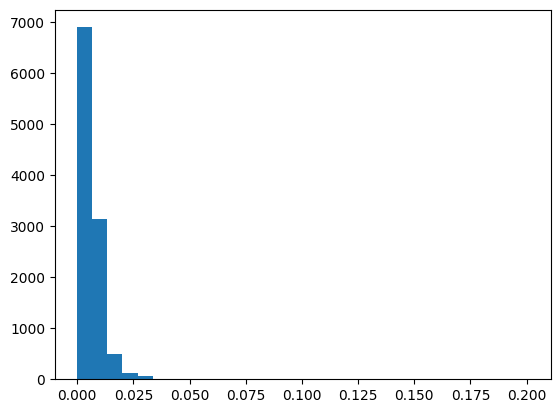

In [41]:
import matplotlib.pyplot as plt
plt.hist(y_df['AE_MSE'].values,30)

(array([1.1606e+04, 9.3000e+02, 2.2900e+02, 8.0000e+01, 3.1000e+01,
        2.3000e+01, 4.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([1.46440478e-04, 1.06951615e-02, 2.12438825e-02, 3.17926036e-02,
        4.23413246e-02, 5.28900456e-02, 6.34387666e-02, 7.39874877e-02,
        8.45362087e-02, 9.50849297e-02, 1.05633651e-01, 1.16182372e-01,
        1.26731093e-01, 1.37279814e-01, 1.47828535e-01, 1.58377256e-01,
        1.68925977e-01, 1.79474698e-01, 1.90023419e-01, 2.00572140e-01,
        2.11120861e-01, 2.21669582e-01, 2.32218303e-01, 2.42767024e-01,
        2.53315745e-01, 2.63864466e-01, 2.74413187e-01, 2.84961908e-01,
        2.95510629e-01, 3.06059350e-01, 3.16608071e-01]),
 <BarContainer object of 30 

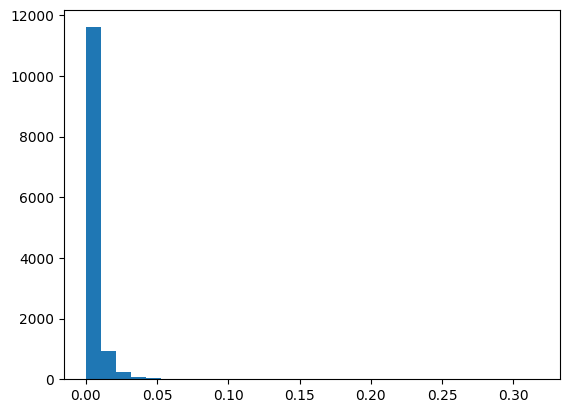

In [44]:
import matplotlib.pyplot as plt
plt.hist(ctrl_df['AE_MSE'].values,30)